In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
## In this example, monthly analyses were conducted for investments made in the months when the currency exchange rate was at its highest
## and lowest. An initial amount of 10,000 was assumed, with the purchase and sale prices of the currency being the same as the exchange 
## rate value.

In [15]:
high_low = pd.read_excel('../data/high_low.xlsx', index_col=0)
percentage_changes = pd.read_excel('../data/percent_changes.xlsx', index_col=0)

percentage_changes_no_index = percentage_changes.reset_index()

In [16]:
initial_investment = 10000
investment_results = []

for currency in high_low.index:
   
    max_date = high_low.loc[currency, 'max_date']
    max_value = high_low.loc[currency, 'max_value']
    min_date = high_low.loc[currency, 'min_date']
    min_value = high_low.loc[currency, 'min_value']
    
    max_change_row = percentage_changes_no_index.loc[percentage_changes_no_index['Date'] == max_date, currency]
    min_change_row = percentage_changes_no_index.loc[percentage_changes_no_index['Date'] == min_date, currency]
    
    if not max_change_row.empty:
        max_change = max_change_row.values[0]
        max_final_value = initial_investment*(1+(max_change / 100))
        max_profit = max_final_value - initial_investment
        max_return = (max_profit / initial_investment)*100
    else:
        max_change = None
        max_final_value = None
        max_profit = None
        max_return = None
    
    if not min_change_row.empty:
        min_change = min_change_row.values[0]
        min_final_value = initial_investment*(1+(min_change / 100))
        min_profit = min_final_value - initial_investment
        min_return = (min_profit / initial_investment)*100
    else:
        min_change = None
        min_final_value = None
        min_profit = None
        min_return = None
    
    investment_results.append({
        'Currency': currency,
        'Max Rate Month': max_date.strftime('%m.%Y') if isinstance(max_date, pd.Timestamp) else max_date,
        'Max Rate Value': max_value,
        'Max Rate Change (%)': max_change,
        'Final Value (Max Rate)': max_final_value,
        'Max Rate Profit': max_profit,
        'Max Rate Return (%)': max_return,
        'Min Rate Month': min_date.strftime('%m.%Y') if isinstance(min_date, pd.Timestamp) else min_date,
        'Min Rate Value': min_value,
        'Min Rate Change (%)': min_change,
        'Final Value (Min Rate)': min_final_value,
        'Min Rate Profit': min_profit,
        'Min Rate Return (%)': min_return
    })

In [17]:
min_max_investment_analysis = pd.DataFrame(investment_results)
min_max_investment_analysis.set_index('Currency', inplace=True)
min_max_investment_analysis

,Max Rate Month,Max Rate Value,Max Rate Change (%),Final Value (Max Rate),Max Rate Profit,Max Rate Return (%),Min Rate Month,Min Rate Value,Min Rate Change (%),Final Value (Min Rate),Min Rate Profit,Min Rate Return (%)
Currency,,,,,,,,,,,,
CHF,9.2023,4.790752,2.962116,10296.211611,296.211611,2.962116,5.2024,4.353320,-1.259779,9874.022126,-125.977874,-1.259779
EUR,9.2023,4.597733,3.093445,10309.344477,309.344477,3.093445,5.2024,4.279990,-0.528909,9947.109101,-52.890899,-0.528909
GPB,9.2023,5.335324,2.709220,10270.922009,270.922009,2.709220,5.2024,5.000565,-0.465706,9953.429375,-46.570625,-0.465706
USD,9.2023,4.303348,5.269086,10526.908644,526.908644,5.269086,5.2024,3.958525,-1.309449,9869.055110,-130.944890,-1.309449
AUD,9.2023,2.764457,4.264948,10426.494831,426.494831,4.264948,3.2024,2.597471,-0.772039,9922.796077,-77.203923,-0.772039
UAH,10.2023,0.116918,0.313851,10031.385105,31.385105,0.313851,6.2024,0.099187,-0.324925,9967.507453,-32.492547,-0.324925
NOK,9.2023,0.401319,2.697643,10269.764278,269.764278,2.697643,4.2024,0.368305,-1.452525,9854.747464,-145.252536,-1.452525


In [18]:
min_max_investment_analysis.to_excel('../data/min_max_investment_analysis.xlsx')

<Figure size 1200x600 with 0 Axes>

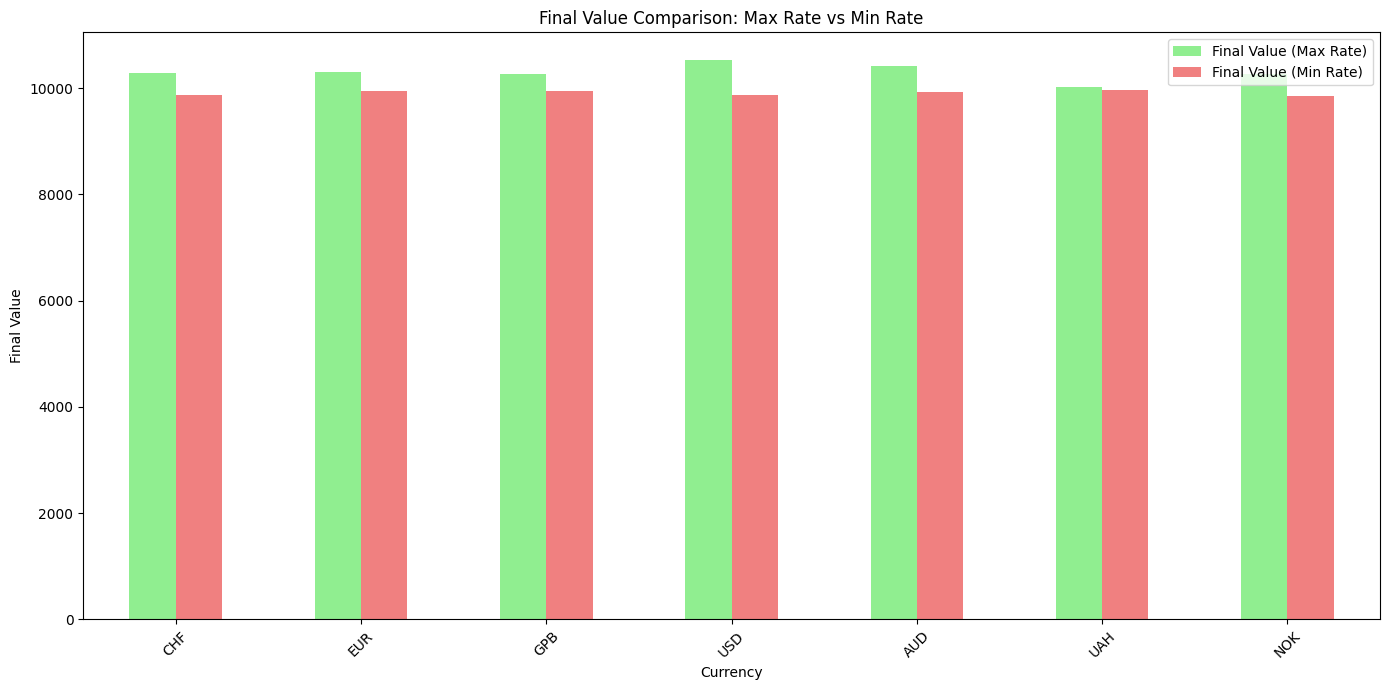

<Figure size 1200x600 with 0 Axes>

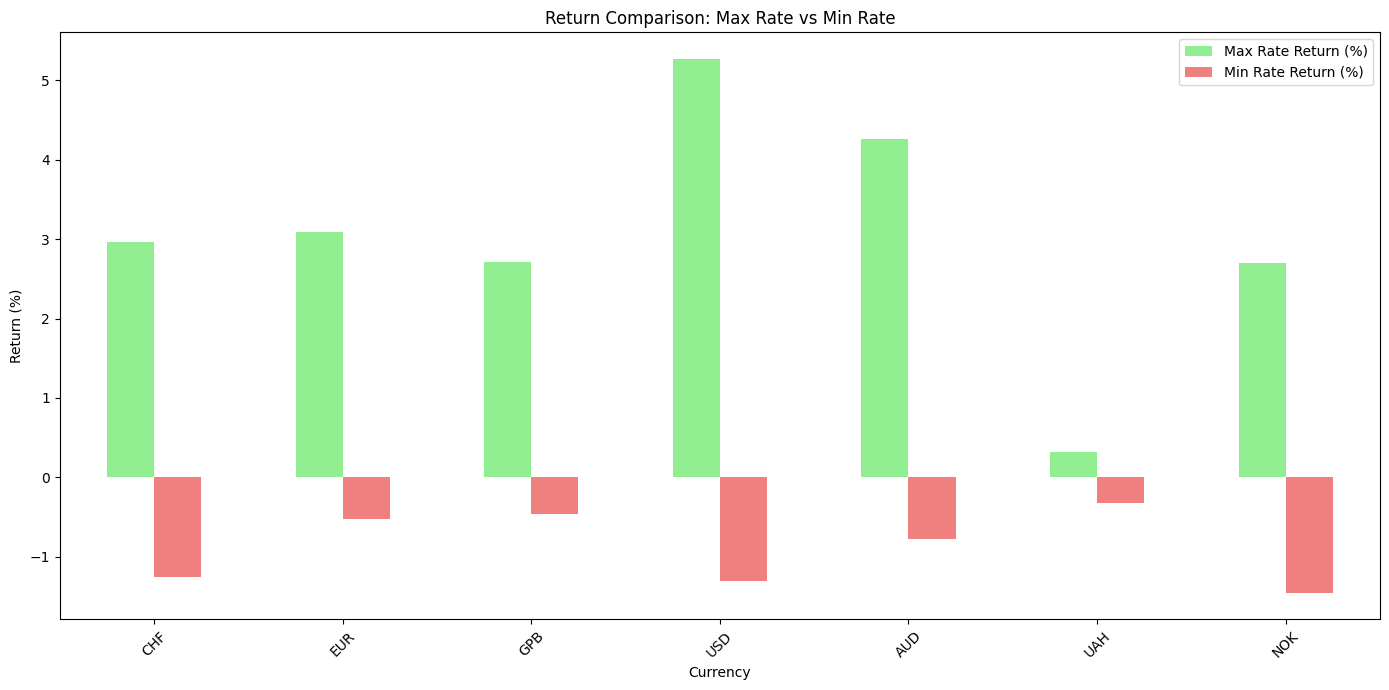

In [19]:
plt.figure(figsize=(12, 6))
ax = min_max_investment_analysis[['Final Value (Max Rate)', 'Final Value (Min Rate)']].plot(kind='bar', color=['lightgreen', 'lightcoral'], figsize=(14, 7))
plt.title('Final Value Comparison: Max Rate vs Min Rate')
plt.xlabel('Currency')
plt.ylabel('Final Value')
plt.xticks(rotation=45)
plt.legend(['Final Value (Max Rate)', 'Final Value (Min Rate)'])

plt.tight_layout()
plt.savefig('../data/min_max_final_value_comparison.pdf')
plt.show()

plt.figure(figsize=(12, 6))
ax = min_max_investment_analysis[['Max Rate Return (%)', 'Min Rate Return (%)']].plot(kind='bar', color=['lightgreen', 'lightcoral'], figsize=(14, 7))
plt.title('Return Comparison: Max Rate vs Min Rate')
plt.xlabel('Currency')
plt.ylabel('Return (%)')
plt.xticks(rotation=45)
plt.legend(['Max Rate Return (%)', 'Min Rate Return (%)'])

plt.tight_layout()
plt.savefig('../data/min_max_return_comparison.pdf')
plt.show()